# Temporal Analysis of River Bank Points (Punten Oever)

**Exploratory Data Analysis: How river bank measurements evolve over time**

## Goals:
1. 📊 Analyze the distribution of measurements across years
2. 🗺️ Visualize river bank points per year on an interactive map
3. 🔍 Identify temporal patterns and data coverage

---

## Setup

In [1]:
import sys
sys.path.append("../../")

import src.paths as PATHS
import src.constants as CONST

import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✅ Imports complete!")

✅ Imports complete!


## Load Data

In [20]:
# Load the base GeoPackage (without WFS data)
INPUT_GPKG = "wocu_output_fase2_v4.gpkg"
input_path = PATHS.DATA_DIR / INPUT_GPKG

print(f"📂 Loading data from: {input_path}")
print(f"\n📋 Available layers:")

layers = gpd.list_layers(input_path)
for idx, row in layers.iterrows():
    print(f"  - {row['name']}: {row['geometry_type']}")

📂 Loading data from: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/wocu_output_fase2_v4.gpkg

📋 Available layers:
  - vlakken_scope: Unknown
  - centrelines: LineString
  - vlakken_erosie: Polygon
  - punten_oever: Unknown


In [21]:
# Load river bank points (punten_oever)
punten_oever = gpd.read_file(input_path, layer="punten_oever")

print(f"📍 Loaded {len(punten_oever):,} river bank points")
print(f"📐 CRS: {punten_oever.crs}")
print(f"\n📊 Shape: {punten_oever.shape}")
print(f"\n🗂️ Columns ({len(punten_oever.columns)}):")
print(list(punten_oever.columns))

📍 Loaded 96,743 river bank points
📐 CRS: EPSG:28992

📊 Shape: (96743, 8)

🗂️ Columns (8):
['z', 'dist', 'type_oever', 'status', 'location_id', 'dtm_version', 'dtm_date', 'geometry']


In [22]:
# Display first few rows
punten_oever.head(10)

,z,dist,type_oever,status,location_id,dtm_version,dtm_date,geometry
0,3.971162,81.784509,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206906.927 474253.385 3.971)
1,3.995932,81.814375,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206906.553 474253.722 3.996)
2,4.092249,82.344816,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206905.823 474253.707 4.092)
3,4.106883,82.625244,steen(bekleding),OUTLIER,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206905.27 474253.868 4.107)
4,4.967876,89.668567,steen(bekleding),OUTLIER,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206899.901 474249.283 4.968)
5,4.966445,89.450701,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206899.703 474249.794 4.966)
6,4.948249,89.232653,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206899.506 474250.305 4.948)
7,4.999294,90.017402,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206898.594 474250.112 4.999)
8,4.940485,89.581122,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206898.199 474251.134 4.94)
9,4.951255,89.362709,steen(bekleding),OK,ijssel1_l_5800_5810,AHN3,2017,POINT Z (206898.002 474251.645 4.951)


In [23]:
# Show data types and non-null counts
punten_oever.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 96743 entries, 0 to 96742
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   z            94467 non-null  float64 
 1   dist         96387 non-null  float64 
 2   type_oever   96743 non-null  str     
 3   status       96387 non-null  str     
 4   location_id  96743 non-null  str     
 5   dtm_version  96743 non-null  str     
 6   dtm_date     96743 non-null  int64   
 7   geometry     96387 non-null  geometry
dtypes: float64(2), geometry(1), int64(1), str(4)
memory usage: 5.9 MB


---

## Temporal Analysis

Analyzing the distribution of river bank measurements across different time periods.

In [24]:
# Identify the timestamp column
# Common possibilities: dtm_date, ahn_version, measurement_date, date, year, etc.
timestamp_cols = [col for col in punten_oever.columns if 'date' in col.lower() or 'time' in col.lower() or 'year' in col.lower() or 'ahn' in col.lower()]

print(f"🕐 Potential timestamp columns: {timestamp_cols}")
print("\n📋 Sample values for each:")
for col in timestamp_cols:
    print(f"\n{col}:")
    print(f"  Type: {punten_oever[col].dtype}")
    print(f"  Unique values: {punten_oever[col].nunique()}")
    print(f"  Sample: {punten_oever[col].unique()[:10]}")

🕐 Potential timestamp columns: ['dtm_date']

📋 Sample values for each:

dtm_date:
  Type: int64
  Unique values: 6
  Sample: [2017 2022 2025 2020 2015 2024]


In [25]:
# Extract year from the timestamp column
# Assuming 'dtm_date' based on demo_baseline_model.ipynb
TIMESTAMP_COL = 'dtm_date'

if TIMESTAMP_COL not in punten_oever.columns:
    # Try alternative names
    for possible_col in ['ahn_version', 'date', 'measurement_date', 'year']:
        if possible_col in punten_oever.columns:
            TIMESTAMP_COL = possible_col
            break

print(f"📅 Using timestamp column: '{TIMESTAMP_COL}'")

# Extract year from the timestamp column
# Check if it's already a year (integer between 1900-2100) or needs datetime conversion
if punten_oever[TIMESTAMP_COL].dtype in ['int64', 'int32', 'int16']:
    # Check if values look like years
    sample_val = punten_oever[TIMESTAMP_COL].iloc[0]
    if 1900 <= sample_val <= 2100:
        # Already stored as year values
        print(f"   ℹ️  Column already contains year values (int)")
        punten_oever['year'] = punten_oever[TIMESTAMP_COL]
    else:
        # Integer but not year format - try to convert
        punten_oever['timestamp'] = pd.to_datetime(punten_oever[TIMESTAMP_COL])
        punten_oever['year'] = punten_oever['timestamp'].dt.year
elif punten_oever[TIMESTAMP_COL].dtype == 'object':
    # String - convert to datetime
    punten_oever['timestamp'] = pd.to_datetime(punten_oever[TIMESTAMP_COL])
    punten_oever['year'] = punten_oever['timestamp'].dt.year
else:
    # Already datetime
    punten_oever['year'] = punten_oever[TIMESTAMP_COL].dt.year

print(f"\n✅ Extracted year column")
print(f"📊 Year range: {punten_oever['year'].min()} - {punten_oever['year'].max()}")

📅 Using timestamp column: 'dtm_date'
   ℹ️  Column already contains year values (int)

✅ Extracted year column
📊 Year range: 2015 - 2025


### Distribution of Measurements by Year

In [26]:
# Count points per year
year_counts = punten_oever['year'].value_counts().sort_index()

print("📊 Points per year:")
print("="*50)
for year, count in year_counts.items():
    bar_length = int(count / year_counts.max() * 40)
    bar = '█' * bar_length
    print(f"{year}: {count:>6,} {bar}")

print("="*50)
print(f"Total: {year_counts.sum():>6,}")
print(f"\n📈 Statistics:")
print(f"  Mean: {year_counts.mean():.0f} points/year")
print(f"  Median: {year_counts.median():.0f} points/year")
print(f"  Std: {year_counts.std():.0f} points/year")
print(f"  Min: {year_counts.min()} points ({year_counts.idxmin()})")
print(f"  Max: {year_counts.max()} points ({year_counts.idxmax()})")

📊 Points per year:
2015:     64 
2017: 32,341 ███████████████████████████████████████
2020:    194 
2022: 32,535 ████████████████████████████████████████
2024:     63 
2025: 31,546 ██████████████████████████████████████
Total: 96,743

📈 Statistics:
  Mean: 16124 points/year
  Median: 15870 points/year
  Std: 17549 points/year
  Min: 63 points (2024)
  Max: 32535 points (2022)


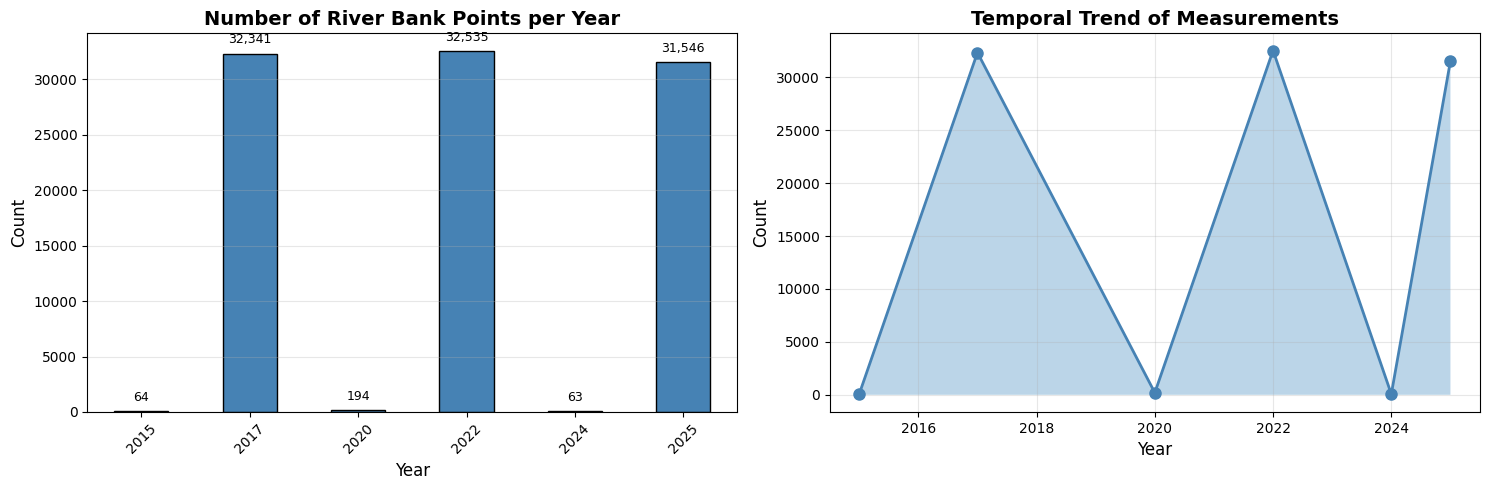

✅ Distribution visualized!


In [27]:
# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Number of River Bank Points per Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (year, count) in enumerate(year_counts.items()):
    axes[0].text(i, count + year_counts.max()*0.02, f'{count:,}', 
                ha='center', va='bottom', fontsize=9)

# Line chart
year_counts.plot(kind='line', ax=axes[1], marker='o', linewidth=2, markersize=8, color='steelblue')
axes[1].set_title('Temporal Trend of Measurements', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].fill_between(year_counts.index, year_counts.values, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Distribution visualized!")

### Additional Statistics by Year

In [28]:
# Group by year and show additional statistics
print("📊 Summary statistics by year:")
print("="*80)

yearly_summary = punten_oever.groupby('year').agg({
    TIMESTAMP_COL: 'count',
    'geometry': lambda x: x.count()
}).rename(columns={TIMESTAMP_COL: 'count', 'geometry': 'valid_geometries'})

# Add percentage
yearly_summary['percentage'] = (yearly_summary['count'] / yearly_summary['count'].sum() * 100).round(2)
yearly_summary['cumulative_pct'] = yearly_summary['percentage'].cumsum().round(2)

print(yearly_summary.to_string())
print("="*80)

📊 Summary statistics by year:
      count  valid_geometries  percentage  cumulative_pct
year                                                     
2015     64                64        0.07            0.07
2017  32341             32190       33.43           33.50
2020    194               194        0.20           33.70
2022  32535             32440       33.63           67.33
2024     63                63        0.07           67.40
2025  31546             31436       32.61          100.01


### Check for data quality issues

In [29]:
# Check for missing values per year
print("🔍 Data quality check:")
print("="*80)

# Missing values
missing_by_year = punten_oever.groupby('year').apply(lambda x: x.isnull().sum()).T
missing_by_year = missing_by_year[missing_by_year.sum(axis=1) > 0]

if len(missing_by_year) > 0:
    print("\n⚠️  Columns with missing values:")
    print(missing_by_year)
else:
    print("\n✅ No missing values found!")

# Check for duplicate geometries
duplicate_geom = punten_oever.duplicated(subset=['geometry']).sum()
print(f"\n🔍 Duplicate geometries: {duplicate_geom:,}")

if duplicate_geom > 0:
    dup_by_year = punten_oever[punten_oever.duplicated(subset=['geometry'], keep=False)].groupby('year').size()
    print("   Distribution by year:")
    print(dup_by_year)

print("="*80)

🔍 Data quality check:

⚠️  Columns with missing values:
year      2015  2017  2020  2022  2024  2025
z            3   952     3   382     2   934
dist         0   151     0    95     0   110
status       0   151     0    95     0   110
geometry     0   151     0    95     0   110

🔍 Duplicate geometries: 691
   Distribution by year:
year
2017    434
2022    118
2025    476
dtype: int64


---

## Interactive Map: River Bank Points by Year

Toggle layers to see how river bank positions shift over time.

In [30]:
# Prepare data for visualization
# Convert to WGS84 for Folium
punten_oever_wgs84 = punten_oever.to_crs(epsg=4326)

# Get center point for map
bounds = punten_oever_wgs84.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

print(f"🗺️  Creating interactive map centered at [{center_lat:.4f}, {center_lon:.4f}]")
print(f"📊 Years available: {sorted(punten_oever['year'].unique())}")

🗺️  Creating interactive map centered at [52.1775, 5.5105]
📊 Years available: [np.int64(2015), np.int64(2017), np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2025)]


In [31]:
# Create color palette for years
years = sorted(punten_oever['year'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
year_colors = {year: f'#{int(c[0]*255):02x}{int(c[1]*255):02x}{int(c[2]*255):02x}' 
               for year, c in zip(years, colors)}

print("🎨 Color palette created:")
for year, color in year_colors.items():
    print(f"  {year}: {color}")

🎨 Color palette created:
  2015: #440154
  2017: #404387
  2020: #29788e
  2022: #22a784
  2024: #79d151
  2025: #fde724


In [32]:
# Create the map
print("🗺️  Building interactive map...")

mapa = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    control_scale=True,
    tiles='OpenStreetMap'
)

# Add a layer for each year
for year in sorted(years):
    year_data = punten_oever_wgs84[punten_oever_wgs84['year'] == year]
    count = len(year_data)
    color = year_colors[year]
    
    # Create feature group for this year
    fg = folium.FeatureGroup(name=f'{year} ({count:,} points)', show=(year == max(years)))
    
    # Add points to the feature group
    for idx, row in year_data.iterrows():
        # Create popup with point information
        popup_html = f"""
        <div style="font-family: Arial; width: 200px;">
            <h4 style="margin-bottom: 10px; color: {color};">River Bank Point</h4>
            <b>Year:</b> {year}<br>
            <b>Date:</b> {row[TIMESTAMP_COL]}<br>
        """
        
        # Add additional attributes if they exist
        interesting_cols = ['location_id', 'position_id', 'region_id', 'id', 'quality', 'status']
        for col in interesting_cols:
            if col in row.index and pd.notna(row[col]):
                popup_html += f"<b>{col.replace('_', ' ').title()}:</b> {row[col]}<br>"
        
        popup_html += "</div>"
        
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            popup=folium.Popup(popup_html, max_width=250),
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            weight=1
        ).add_to(fg)
    
    fg.add_to(mapa)
    print(f"  ✅ Added layer for {year}: {count:,} points (color: {color})")

# Add layer control
folium.LayerControl(position='topright', collapsed=False).add_to(mapa)

# Add title
title_html = '''
<div style="position: fixed; 
     top: 10px; left: 50px; width: 400px; height: 60px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:16px; padding: 10px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
     ">
     <h4 style="margin: 0;">🗺️ River Bank Points by Year</h4>
     <p style="margin: 5px 0 0 0; font-size: 12px; color: #666;">
     Toggle layers to see temporal evolution
     </p>
</div>
'''
mapa.get_root().html.add_child(folium.Element(title_html))

print("\n✅ Map created!")
print("💡 Use the layer control (top right) to toggle years on/off")
print("💡 Click on points to see details")

mapa

🗺️  Building interactive map...
  ✅ Added layer for 2015: 64 points (color: #440154)


AttributeError: 'NoneType' object has no attribute 'y'

---

## Additional Analysis: Spatial Clustering by Year

In [17]:
# Optional: Load scope regions to see coverage
scope_regions = gpd.read_file(input_path, layer="vlakken_scope")

print(f"📍 Loaded {len(scope_regions)} scope regions")

# Count how many points fall within each scope region per year
# (This is a spatial join - can be slow with many points)
print("\n🔄 Performing spatial join to count points per region per year...")
print("   (This may take a moment)")

📍 Loaded 233 scope regions

🔄 Performing spatial join to count points per region per year...
   (This may take a moment)


In [18]:
# Spatial join
# Find the ID column in scope_regions
region_id_col = None
for possible_id in ['location_id', 'position_id', 'region_id', 'id']:
    if possible_id in scope_regions.columns:
        region_id_col = possible_id
        break

print(f"\n🔑 Using region ID column: {region_id_col}")

joined = gpd.sjoin(punten_oever, scope_regions[['geometry', region_id_col]], how='left', predicate='within')

# Count points per region per year
coverage_by_year = joined.groupby(['year', region_id_col]).size().reset_index(name='point_count')

# Pivot to see year x region matrix
coverage_matrix = coverage_by_year.pivot(index=region_id_col, columns='year', values='point_count').fillna(0).astype(int)

print("\n📊 Points per region per year:")
print(coverage_matrix.head(20))

# Summary
print("\n📈 Coverage statistics:")
regions_per_year = (coverage_matrix > 0).sum(axis=0)
print(f"\nRegions with measurements per year:")
for year, count in regions_per_year.items():
    pct = count / len(scope_regions) * 100
    print(f"  {year}: {count}/{len(scope_regions)} regions ({pct:.1f}%)")


🔑 Using region ID column: location_id


KeyError: 'location_id'

NameError: name 'regions_per_year' is not defined

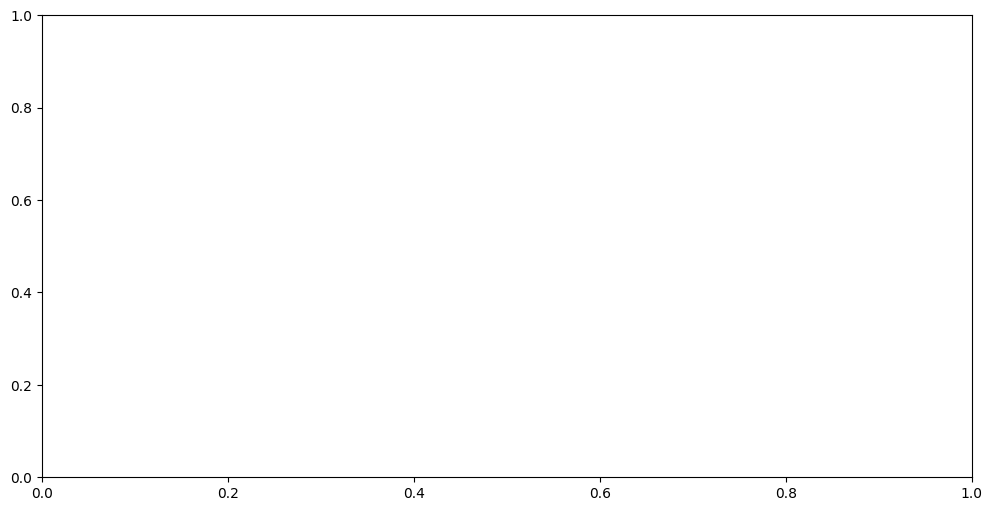

In [19]:
# Visualize coverage over time
fig, ax = plt.subplots(figsize=(12, 6))

regions_per_year.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.axhline(len(scope_regions), color='red', linestyle='--', linewidth=2, label=f'Total regions ({len(scope_regions)})')
ax.set_title('Spatial Coverage: Number of Regions with Measurements per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Regions', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Add percentage labels
for i, (year, count) in enumerate(regions_per_year.items()):
    pct = count / len(scope_regions) * 100
    ax.text(i, count + 2, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Coverage analysis complete!")

---

## Summary

**Key Findings:**
- Review the temporal distribution above
- Check the interactive map to see spatial-temporal patterns
- Note any years with unusually high/low coverage
- Identify regions with consistent measurements across years